In [1]:
import os

# 1. Ver dónde estás parado actualmente
print("Directorio original:", os.getcwd())

# 2. Configurar la ruta raíz de tu proyecto
# Reemplaza esto con tu ruta real de Windows/WSL
# Ejemplo usando tu posible estructura de usuario:
ruta_proyecto = '/home/rsphobos/PROYECTOS_GABO/MCP_LangGraph_Project' 

# 3. Mover la ejecución a esa carpeta
os.chdir(ruta_proyecto)
print("Nuevo directorio de ejecución:", os.getcwd())

Directorio original: /home/rsphobos/PROYECTOS_GABO/MCP_LangGraph_Project/notebooks
Nuevo directorio de ejecución: /home/rsphobos/PROYECTOS_GABO/MCP_LangGraph_Project


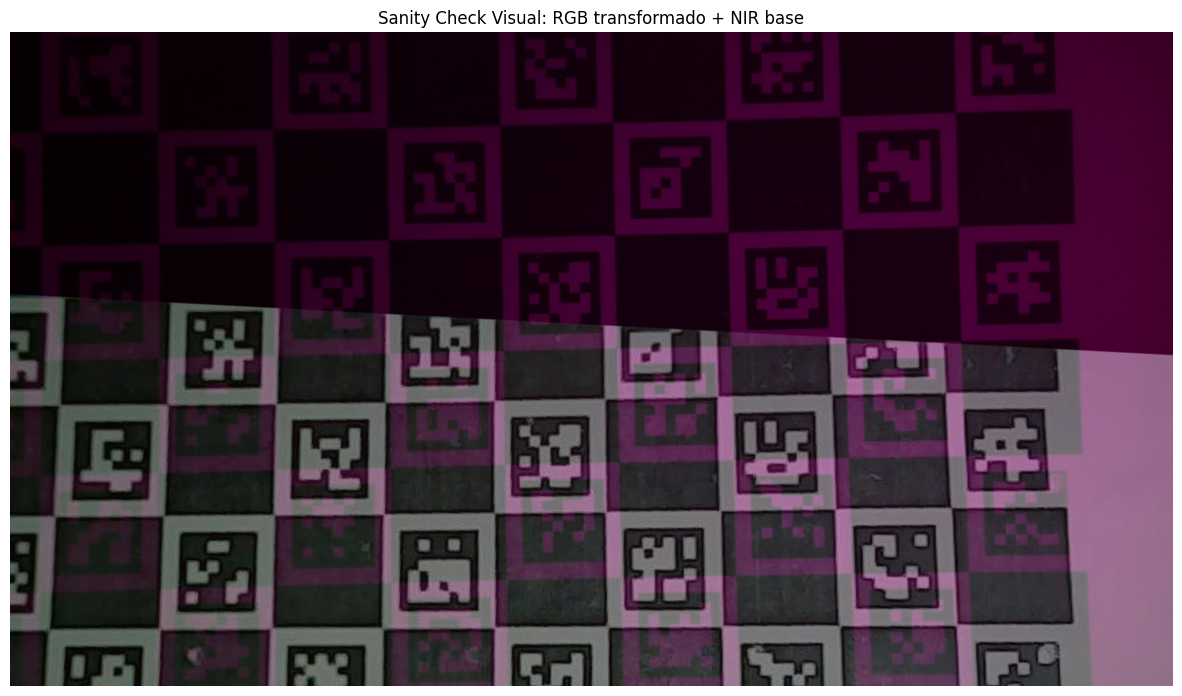

📸 Imagen de prueba guardada como 'resultado_fusión.jpg'


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CARGAR DATOS ---
# Carga tu matriz recién horneada
H = np.load('notebooks/matriz_homografia_charuco.npy')

# Rutas de un par de fotos de prueba (Reemplaza con el nombre de un archivo real)
ruta_rgb = 'notebooks/mango_rgb_1775347522.jpg'
ruta_nir = 'notebooks/mango_nir_1775347522.jpg'

img_rgb = cv2.imread(ruta_rgb)
img_nir = cv2.imread(ruta_nir)

# --- 2. TRANSFORMACIÓN ESPACIAL (WARPING) ---
# Sacamos el alto y ancho de la imagen NIR (que es nuestro plano base / FOV estrecho)
h_nir, w_nir = img_nir.shape[:2]

# Deformamos la imagen RGB usando la Matriz H para que encaje en la perspectiva NIR
rgb_alineada = cv2.warpPerspective(img_rgb, H, (w_nir, h_nir))

# --- 3. ALPHA BLENDING (FUSIÓN 50/50) ---
# Si tu foto NIR la lee como 1 solo canal (escala de grises), la pasamos a 3 canales 
# para que cv2.addWeighted no tire error al mezclarla con la RGB.
if len(img_nir.shape) == 2:
    img_nir = cv2.cvtColor(img_nir, cv2.COLOR_GRAY2BGR)

# Superponemos las imágenes al 50% de opacidad cada una
mezcla = cv2.addWeighted(rgb_alineada, 0.5, img_nir, 0.5, 0)

# --- 4. VISUALIZACIÓN ---
plt.figure(figsize=(15, 10))
plt.title("Sanity Check Visual: RGB transformado + NIR base")
# Convertimos de BGR a RGB para que Matplotlib muestre los colores correctos
plt.imshow(cv2.cvtColor(mezcla, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# Opcional: Guardarla en alta resolución para hacerle zoom con tus propios ojos
cv2.imwrite('resultado_fusión.jpg', mezcla)
print("📸 Imagen de prueba guardada como 'resultado_fusión.jpg'")